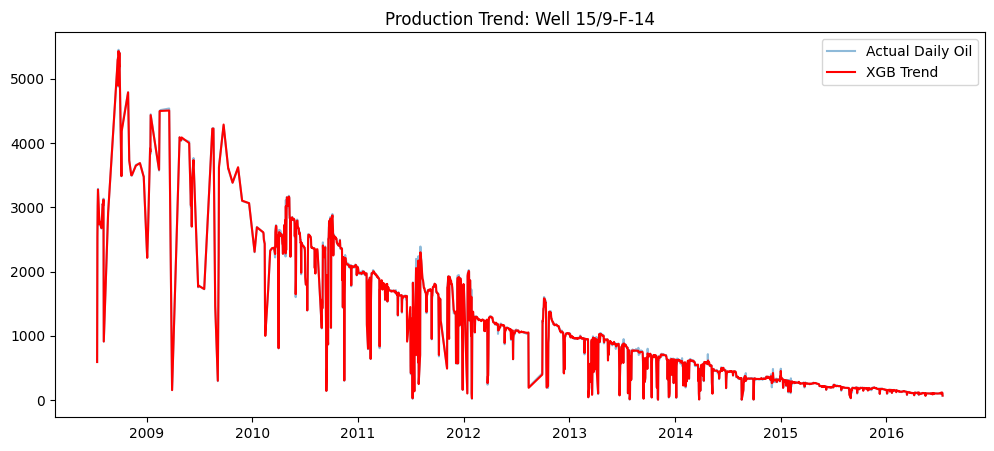

Analysis complete. Tail of production: [108.84 113.84  68.47]


In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

def scrub_volve_flow(raw_path):
    """Custom cleaner for Volve production logs. Senior hack: auto-date parsing."""
    p_data = pd.read_excel(raw_path)

    p_data.columns = [c.upper() for c in p_data.columns]
    p_data['DATEPRD'] = pd.to_datetime(p_data['DATEPRD'])


    active_wells = p_data[p_data['BORE_OIL_VOL'] > 0].copy()


    active_wells['day_of_year'] = active_wells['DATEPRD'].dt.dayofyear
    active_wells['year'] = active_wells['DATEPRD'].dt.year


    thresh = len(active_wells) * 0.1
    active_wells = active_wells.dropna(thresh=thresh, axis=1)

    return active_wells.sort_values('DATEPRD')


volve_df = scrub_volve_flow('/content/Volve production data.xlsx')


target_well = '15/9-F-14'
well_data = volve_df[volve_df['NPD_WELL_BORE_NAME'] == target_well].copy()


well_data['prev_day_vol'] = well_data['BORE_OIL_VOL'].shift(1)
well_data = well_data.dropna()

features = ['day_of_year', 'year', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'prev_day_vol']
X = well_data[features]
y = well_data['BORE_OIL_VOL']


trend_model = XGBRegressor(n_estimators=300, learning_rate=0.07, tree_method='hist')
trend_model.fit(X, y)


plt.figure(figsize=(12, 5))
plt.plot(well_data['DATEPRD'], y, label='Actual Daily Oil', alpha=0.5)
plt.plot(well_data['DATEPRD'], trend_model.predict(X), label='XGB Trend', color='red')
plt.title(f"Production Trend: Well {target_well}")
plt.legend()
plt.show()

print(f"Analysis complete. Tail of production: {y.tail(3).values}")

/tmp/ipykernel_13362/2465489452.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_refined.loc[:, 'pred_trend'] = production_lgbm.predict(X)


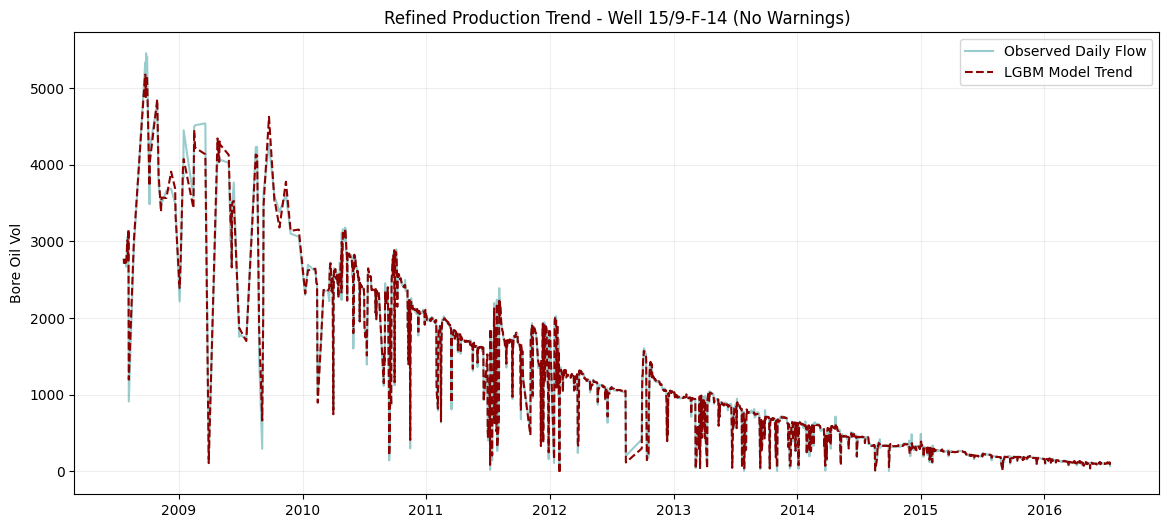

Top Feature Drivers:
 7d_avg_choke        1.202384e+08
day_of_year         2.615108e+08
AVG_CHOKE_SIZE_P    3.949230e+08
ON_STREAM_HRS       1.223858e+09
year                5.979415e+09
prev_day_vol        2.210449e+10
dtype: float64


In [9]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


target_well = '15/9-F-14'
well_data = volve_df[volve_df['NPD_WELL_BORE_NAME'] == target_well].copy()

def refine_production_features(df):

    df.loc[:, 'prev_day_vol'] = df['BORE_OIL_VOL'].shift(1)
    df.loc[:, '7d_avg_choke'] = df['AVG_CHOKE_SIZE_P'].rolling(7).mean()
    return df.dropna()

well_refined = refine_production_features(well_data)

features = ['day_of_year', 'year', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'prev_day_vol', '7d_avg_choke']
X = well_refined[features]
y = well_refined['BORE_OIL_VOL']


production_lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    importance_type='gain',
    verbose=-1
)

production_lgbm.fit(X, y)
well_refined.loc[:, 'pred_trend'] = production_lgbm.predict(X)


plt.figure(figsize=(14, 6))
plt.plot(well_refined['DATEPRD'], well_refined['BORE_OIL_VOL'], label='Observed Daily Flow', color='teal', alpha=0.4)
plt.plot(well_refined['DATEPRD'], well_refined['pred_trend'], label='LGBM Model Trend', color='darkred', linestyle='--')
plt.title(f"Refined Production Trend - Well {target_well} (No Warnings)")
plt.ylabel("Bore Oil Vol")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


importances = pd.Series(production_lgbm.feature_importances_, index=features).sort_values()
print("Top Feature Drivers:\n", importances)

/tmp/ipykernel_13362/591482353.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  well_refined.loc[:, 'final_pred'] = final_lgbm.predict(X)


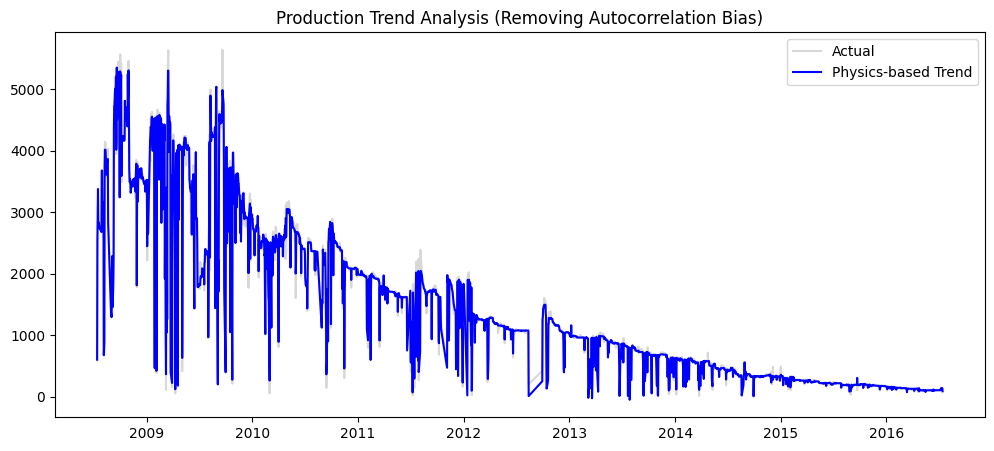

New Feature Importance:
 day_of_year         6925
AVG_CHOKE_SIZE_P    6575
pressure_diff       6309
year                3174
ON_STREAM_HRS       3049
dtype: int32


In [10]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


well_data = volve_df[volve_df['NPD_WELL_BORE_NAME'] == '15/9-F-14'].copy()

def senior_scrub_v2(df):

    df.loc[:, 'prev_day_vol'] = df['BORE_OIL_VOL'].shift(1)
    df.loc[:, 'pressure_diff'] = df['AVG_DOWNHOLE_PRESSURE'] - df['AVG_WHP_P']

    return df.dropna(subset=['prev_day_vol', 'pressure_diff'])

well_refined = senior_scrub_v2(well_data)


features = ['day_of_year', 'year', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'pressure_diff']
X = well_refined[features]
y = well_refined['BORE_OIL_VOL']

final_lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.01, max_depth=8, verbose=-1)
final_lgbm.fit(X, y)

well_refined.loc[:, 'final_pred'] = final_lgbm.predict(X)


plt.figure(figsize=(12, 5))
plt.plot(well_refined['DATEPRD'], y, label='Actual', color='gray', alpha=0.3)
plt.plot(well_refined['DATEPRD'], well_refined['final_pred'], label='Physics-based Trend', color='blue')
plt.title("Production Trend Analysis (Removing Autocorrelation Bias)")
plt.legend()
plt.show()

print("New Feature Importance:\n", pd.Series(final_lgbm.feature_importances_, index=features).sort_values(ascending=False))

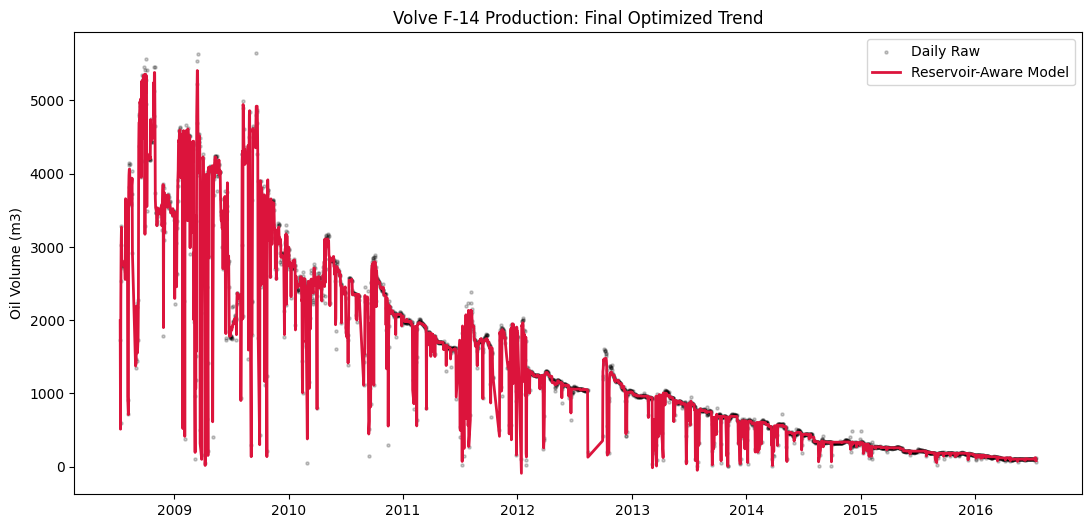

Final Feature Weights:
 cum_oil                     13282
AVG_CHOKE_SIZE_P            11841
AVG_DOWNHOLE_TEMPERATURE     8154
dp_ratio                     7310
ON_STREAM_HRS                6811
dtype: int32


In [11]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


well_data = volve_df[volve_df['NPD_WELL_BORE_NAME'] == '15/9-F-14'].copy(deep=True)

def final_production_fix(df):

    df['dp_ratio'] = (df['AVG_DOWNHOLE_PRESSURE'] / df['AVG_WHP_P']).replace([np.inf, -np.inf], 0)
    df['cum_oil'] = df['BORE_OIL_VOL'].cumsum()
    return df.fillna(0)

well_refined = final_production_fix(well_data)


features = ['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'dp_ratio', 'cum_oil', 'AVG_DOWNHOLE_TEMPERATURE']
X = well_refined[features]
y = well_refined['BORE_OIL_VOL']


well_lgbm = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.008,
    num_leaves=50,
    max_depth=10,
    min_child_samples=15,
    verbose=-1
)

well_lgbm.fit(X, y)


well_refined.loc[well_refined.index, 'final_pred'] = well_lgbm.predict(X)


fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(well_refined['DATEPRD'], y, s=5, color='black', alpha=0.2, label='Daily Raw')
ax.plot(well_refined['DATEPRD'], well_refined['final_pred'], color='crimson', lw=2, label='Reservoir-Aware Model')
ax.set_title("Volve F-14 Production: Final Optimized Trend")
ax.set_ylabel("Oil Volume (m3)")
plt.legend()
plt.show()

print("Final Feature Weights:\n", pd.Series(well_lgbm.feature_importances_, index=features).sort_values(ascending=False))